# 문제 1. 기초통계량 계산
**📘 문제**
- 온라인 쇼핑몰 고객 1,000명을 대상으로 1점부터 10점 사이의 만족도 조사를 실시했습니다.
이 데이터를 바탕으로 고객 만족도의 **중심 경향성**과 **분포 특성**을 파악해 봅시다.

<br>

**📌 아래를 수행해 보세요:**

  - 평균, 중앙값, 최빈값, 표준편차를 계산해 봅시다.
  - 히스토그램을 그리고 평균과 중앙값 선으로 표시해 봅시다.
  - 데이터의 분포 형태를 해석한 후, 마케팅 전략 수립에 어떻게 활용할 수 있을지 생각해 봅시다.

In [ ]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 아래 코드 실행 후, [런타임] - [세션 다시 시작] 필요
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumGothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

In [ ]:
# 데이터 생성
np.random.seed(2025)
satisfaction = np.random.normal(7.5, 1.5, 1000)
satisfaction = np.clip(satisfaction, 1, 10)
df1 = pd.DataFrame({'score': satisfaction})

In [ ]:
#데이터 확인
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   score   1000 non-null   float64
dtypes: float64(1)
memory usage: 7.9 KB


,score
count,1000.000000
mean,7.428690
std,1.392671
min,2.724405
25%,6.469893
50%,7.421731
75%,8.437992
max,10.000000


In [ ]:
#최빈값
df1["score"].mode().tolist()

[10.0]

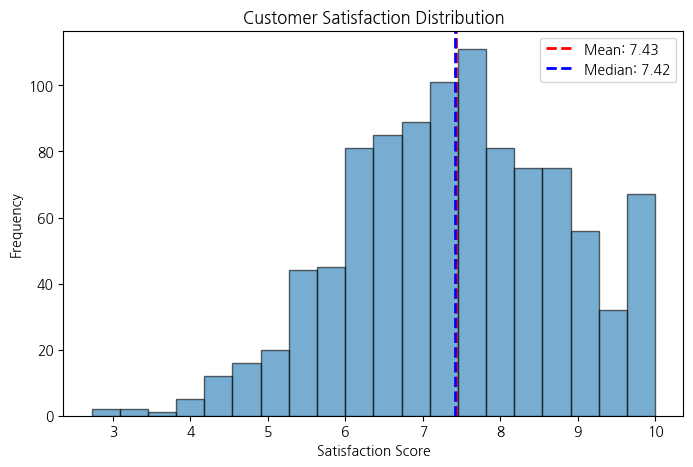

In [ ]:
#히스토그램
plt.figure(figsize=(8,5))
plt.hist(df1["score"], bins=20, alpha=0.6, edgecolor='black')

# 평균과 중앙값 선 표시
plt.axvline(mean_value, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_value:.2f}")
plt.axvline(median_value, color='blue', linestyle='--', linewidth=2, label=f"Median: {median_value:.2f}")

plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

1. 평균과 중앙값 사이의 차이는 어느 정도인가요?

    - 두 값이 비슷하다면, 이 데이터는 어떤 분포 형태일 가능성이 있을까요? (예: 대칭형, 정규분포 등)
    - 두 값의 차이가 크다면, 그 이유는 무엇일까요?
    - 어떤 값들이 평균을 끌어내리거나 끌어올렸을까요?

2. 최빈값이 평균보다 낮은 경우, 낮은 점수를 준 고객이 많다는 뜻일 수 있습니다. 이 경우 데이터 분포는 어느 쪽으로 치우쳐 있을까요?
    - 반대로 최빈값이 평균보다 높은 경우에는 어떤 해석이 가능할까요? 이럴 때 분포가 어떻게 달라질 수 있을까요?

3. 이 데이터를 바탕으로 고객 만족도를 높이기 위한 마케팅 전략에는 어떤 것들이 있을까요?

[답변]
1. 0.1 정도 차이남.
- 대칭형
- 두 값 차이가 큰 편이 아니라고 생각함. 만약 크다면 롱테일 구조일 가능성 (값의 분포가 평균 기준 특정 방향쪽으로의 쏠림이 있는 경우)
- 평균을 끌어내린건 최솟값 방향 쪽에 퍼진 값들

2. 최빈값이 평균보다 낮은 경우 데이터 분포는 낮은쪽으로 치우치려는 경향, 반대로 최빈값이 평균 값보다 높으면 데이터 분포가 높은 점수쪽으로 치우치려는 경향 (오른쪽에 값이 치우치는 모양. 오른쪽이 더 채워져있는 현상).
3. 데이터를 보면 안정적인 점수를 주는 층이 두텁지만, 일부 리스크 고객 존재
- 충성고객 (이미 안정적인 층) 락인 전략 : 이미 만족하고 있는 고객들은 신규 고객 추천유도 하면 보상 제공
- 낮은 점수 일부 고객들의 불만족 (리스크) 원인 분석 후 특별 케어로 불만 해소  

# 문제 2. 평균 vs 중앙값 비교
**📘 문제**
- A지역과 B지역의 연봉 데이터를 비교해 봅시다.
- B 지역에는 일부 고소득자가 포함되어 있습니다.

<br>

**📌 아래를 수행해 보세요:**
- 각 지역의 평균 연봉과 중앙값을 구해 봅시다.
- 지역별 박스플롯(Boxplot)을 그려서 분포의 차이를 시각적으로 확인해 봅시다.

In [ ]:
# 데이터 생성
np.random.seed(2025)

# A 지역: 평균 300, 표준편차 50
region_a = np.random.normal(300, 50, 100)

# B 지역: 일반 소득자 + 극단적인 고소득자 포함
region_b = np.concatenate([
    np.random.normal(280, 40, 95),    # 일반 소득자 95명
    np.random.normal(1500, 200, 5)    # 고소득자 5명
])

df2 = pd.DataFrame({
    'region': ['A'] * 100 + ['B'] * 100,
    'salary': np.concatenate([region_a, region_b])
})

In [ ]:
# 데이터 확인
region_a = df2[df2['region'] == 'A']
region_a.head()

,region,salary
0,A,295.380491
1,A,336.714279
2,A,228.055899
3,A,266.828899
4,A,294.963596


In [ ]:
# 데이터 확인
region_b = df2[df2['region'] == 'B']
region_b.head()

,region,salary
100,B,337.417491
101,B,349.076385
102,B,254.357580
103,B,313.365233
104,B,302.233956


In [ ]:
#각 지역별 평균이랑 중앙값
print("A 지역 평균:", region_a['salary'].mean())
print("A 지역 중앙값:", region_a['salary'].median())

print("B 지역 평균:", region_b['salary'].mean())
print("B 지역 중앙값:", region_b['salary'].median())

A 지역 평균: 292.5066374901889
A 지역 중앙값: 294.32448331703154
B 지역 평균: 347.5949090667186
B 지역 중앙값: 287.34748777411573


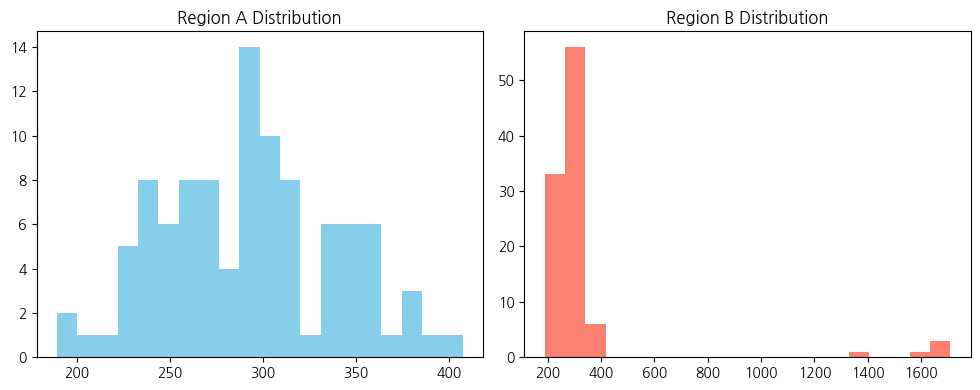

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(region_a['salary'], bins=20, color='skyblue')
plt.title("Region A Distribution")

plt.subplot(1,2,2)
plt.hist(region_b['salary'], bins=20, color='salmon')
plt.title("Region B Distribution")

plt.tight_layout()
plt.show()

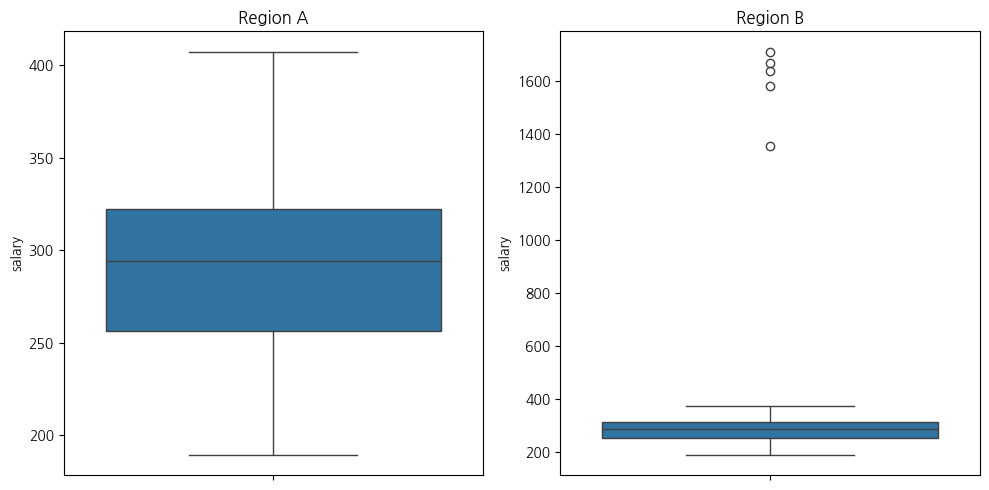

In [ ]:
# 박스 플롯
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(y=region_a['salary'])
plt.title("Region A")

plt.subplot(1,2,2)
sns.boxplot(y=region_b['salary'])
plt.title("Region B")

plt.tight_layout()
plt.show()

A는 대칭형, B는 오른쪽 극단값들이 존재하는 형태

**🧠 데이터를 어떻게 읽을까요?**
1. A 지역과 B 지역의 평균 연봉은 어떻게 다른가요?
    - 두 지역의 평균 차이가 의미하는 바는 무엇인가요?
    - 고소득자가 있는 지역의 평균은 어떤 영향을 받을까요?

2. 중앙값은 어떠한가요?
    - 평균과 비교했을 때, 중앙값이 더 낮거나 높다면 어떤 해석이 가능할까요?

3. 극단값(고소득자)의 영향은 어디에서 더 크게 나타날까요?
    - 평균과 중앙값 중 어떤 지표가 극단값에 더 민감한가요?

4. 박스플롯을 통해 어떤 점을 관찰할 수 있나요?
    - 이상치(Outlier)는 어떻게 표시되나요?
    - 두 지역의 분포 폭(사분위 범위)은 어떻게 다른가요?

5. 평균만 보고 판단했을 때 생길 수 있는 오해는 무엇인가요?
    - 어떤 경우에는 중앙값이 더 유용한 지표일 수 있을까요?




1. A지역 평균 연봉은 약 292, B지역 평균 연봉은 347임. 하지만 A지역은 분포가 대칭형이고, B는 오른쪽 극단값이 존재해서 평균이 오른쪽으로 치우침이 발생한 것으로 생각할 수 있음. 단순히 평균값만 보면 A 지역 사람보다 B 지역 사람들이 연봉이 높은 사람이 많을 거라고 생각할 수 있지만 현실은 그렇지 않다.
2. 중앙값은 평균보다 낮으면 고소득자 연봉이 평균을 높이는 영향을 주고 있고, 중앙값이 평균보다 높으면 저소득자의 연봉이 평균을 낮추는 영향을 줄 가능성이 높음. 여기서는 오히려 중앙값이 서로 비슷함.
3. 본 데이터를 봤을 때 극단값에 민감한 영향을 받는 것은 평균값임을 알 수 있음.
4. 이상치는 IQR 바깥쪽에 보이는데 B 그룹에서 위쪽에 찍힘 점들로 표현되고 있음. A는 4분위 분포면에서 안정적인 퍼짐의 대칭형으로 보여 가운데 50%인 중간층의 다양성이 어느정도 큰 편이지만 B지역은 상대적으로 데이터 몰림 구간(박스구간)이 A보다 좁으므로 가운데 50% 중간 소득층이 비교적 균일하다는 의미임.

# 문제 3. 이상값과 분산 비교
**📘 문제**
- 1반과 2반의 시험 점수 분포를 비교해 봅시다.
- 2반에는 극단적인 이상값(예: 부정행위로 0점)이 포함되어 있습니다.

<br>

**📌 아래를 수행해 보세요:**
1. 각 반의 평균, 표준편차, 최소/최대값을 계산해 봅시다.
2. 박스플롯을 사용하여 두 반의 분포 차이를 시각적으로 비교해 봅시다.
3. 이상값이 통계 지표에 어떤 영향을 주는지 생각해 봅시다.


In [ ]:
# 데이터 생성
np.random.seed(2025)  # 재현 가능성을 위해 시드 고정

# 1반: 평균 75, 표준편차 8
class1 = np.random.normal(75, 8, 30)

# 2반: 일반 학생 + 이상값(0점, 130점)
class2 = np.concatenate([
    np.random.normal(75, 15, 28),  # 일반 학생
    [0, 130]                       # 극단적인 이상값
])

df3 = pd.DataFrame({
    'class': ['1반'] * 30 + ['2반'] * 30,
    'score': np.concatenate([class1, class2])
})

In [ ]:
#데이타 구분
class1_df = df3[df3['class'] == '1반']
class2_df = df3[df3['class'] == '2반']

In [ ]:
#각 반 통계치 보기
print(class1_df.describe())
print(class2_df.describe())

           score
count  30.000000
mean   75.724316
std     7.062710
min    60.685416
25%    73.378207
50%    74.750510
75%    80.841514
max    92.175893
            score
count   30.000000
mean    73.728848
std     22.340818
min      0.000000
25%     60.751642
50%     73.003726
75%     88.365078
max    130.000000


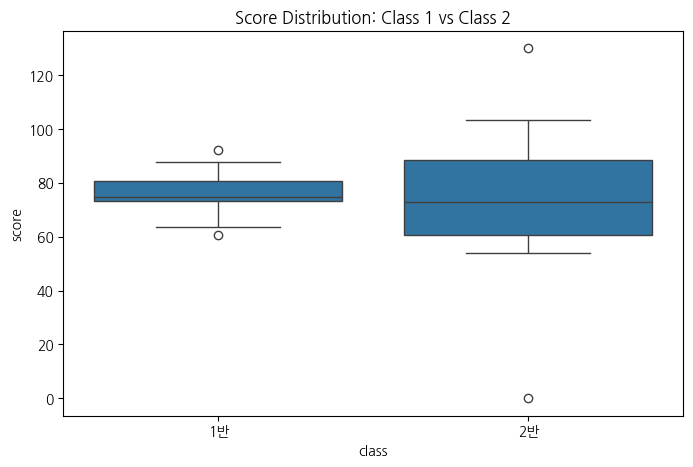

In [ ]:
# 박스 플롯

plt.figure(figsize=(8,5))
sns.boxplot(data=df3, x='class', y='score')
plt.title("Score Distribution: Class 1 vs Class 2")
plt.show()

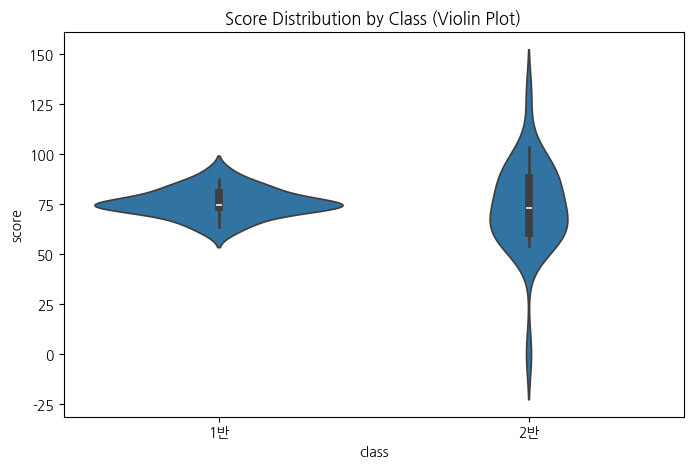

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df3, x='class', y='score')
plt.title("Score Distribution by Class (Violin Plot)")
plt.show()

**🧠 데이터를 어떻게 읽을까요?**
1. 어떤 반의 점수 분산이 더 크고, 왜 그럴까요?
    - 점수 분포의 퍼짐 정도는 어떤 지표로 확인할 수 있을까요?
    - 이상값이 포함되면 표준편차나 범위는 어떻게 달라질까요?

2. 이상값이 있는 반의 평균은 어떤 영향을 받았나요?
    - 극단적으로 낮거나 높은 점수가 평균을 끌어내리거나 끌어올렸나요?
    - 평균과 중앙값의 차이가 의미하는 바는 무엇인가요?

3. 박스플롯을 통해 이상값은 어떻게 드러나나요?
    - 이상값(outlier)은 박스플롯에서 어떤 형태로 나타나나요?
    - 두 반의 박스(사분위 범위)는 어떻게 다르게 보이나요?

4. 평균만 보고 평가했을 때 생길 수 있는 오해는 무엇인가요?
    - 예를 들어, 교사가 평균 점수만 보고 2반이 부족하다고 판단한다면?
    - 중앙값이나 표준편차 같은 지표와 함께 분석하는 것은 왜 중요할까요?

1. 2반의 분산 (std 표준편차) 값을 봤을 때 상대적으로 더 크다. 퍼짐이 더 크다는 이야기.
2. 2번은 이상값이 위아래 있음. 중간값은 정상범위이나 평균이
3. 박스플롯에서 이상값은 박스 바깥쪽에 점으로 나옴, 사분위 범위 IQR이 1반은 몰려있고 (서로 값들이 비슷하다), 2반은 위아래로 퍼져있어 다양한 값들이 존재함을 알 수 있음
4. 평균은 이상값에 매우 민감하고 이것을 표준편차로 우리는 잘 캐치해낼 수 있음. 따라서 평균만 보고 판단하는 것은 데이터 분포 유형에 따라 왜곡된 해석을 야기할 수 있음. 중앙값과 표준편차 등을 함께 봐서 어떤 것이 데이터를 잘 대표할 수 있을 지 고민해야 함.

# 문제 4. IQR 이상값 제거
**📘 문제**
- 앞의 문제에서 2반에는 **극단적인 이상값(예: 매우 낮은 점수)**이 포함되어 있어
통계 지표, 특히 평균에 큰 영향을 주는 것을 확인했습니다.
- 이번에는 **IQR(사분위 범위)**을 기준으로 이상값을 제거한 뒤, 이상값 제거 전후의 평균을 비교해 봅시다

<br>

**📌 아래를 수행해 보세요:**
- 2반의 점수 데이터를 대상으로 IQR 기준을 사용해 이상값을 판별하고 제거해 봅시다.
- 이상값 제거 전과 제거 후의 평균을 각각 계산해 봅시다.
- 이상값 제거가 평균에 어떤 영향을 주는지 설명해 봅시다.
- 필요하다면 중앙값과도 비교해 봅시다.

In [ ]:
# 2반 데이터 IQR 계산하기
class2new = class2_df['score']

Q1 = class2new.quantile(0.25)
Q3 = class2new.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Q1, Q3, IQR, lower_bound, upper_bound

(np.float64(60.75164177527343),
 np.float64(88.36507764647857),
 np.float64(27.61343587120514),
 np.float64(19.331487968465716),
 np.float64(129.7852314532863))

In [ ]:
class2_clean = class2new[(class2new >= lower_bound) & (class2new <= upper_bound)]

In [ ]:
mean_before = class2new.mean()
mean_after = class2_clean.mean()

print("제거 전 평균:", mean_before)
print("제거 후 평균:", mean_after)

제거 전 평균: 73.72884842544566
제거 후 평균: 74.35233759869178


In [ ]:
median_before = class2new.median()
median_after = class2_clean.median()

print("제거 전 중앙값:", median_before)
print("제거 후 중앙값:", median_after)

제거 전 중앙값: 73.00372633167626
제거 후 중앙값: 73.00372633167626


**🧠 데이터를 어떻게 읽을까요?**
1. 이상값 제거 전후 평균은 어떻게 달라졌나요?
    - 평균이 중앙값에 가까워졌나요?
    - 이상값 제거가 평균에 어떤 방향으로 영향을 주었나요?

2. 왜 IQR을 기준으로 이상값을 판단할까요?
    - IQR은 데이터를 어떻게 나누고, 어떤 방식으로 이상값을 정의하나요?
    - 평균이나 표준편차 기준과 비교했을 때 어떤 점이 더 강건할까요?

3. 이상값은 언제 제거하고, 언제 유지해야 할까요?
    - 분석 목적에 따라 이상값은 중요한 정보가 될 수 있습니다.

4. 중앙값과 평균은 각각 어떤 상황에서 더 유용한 지표인가요?
    - 이상값이 있을 때 어떤 지표가 더 신뢰할 수 있나요?
    - 두 지표를 함께 보면 어떤 장점이 있을까요?

1. 평균이 전보다 올라감. 중앙값은 차이가 없음. 평균은 오히려 중앙값에서 멀어짐.
2. IQR는 데이터를 4분위로 나눈뒤 가운데 50% 폭을 표현한다. 평균이나 표준편차에 비해서 극단값에 영향을 받지 않는 중간층 분포를 보고 이상값을 정의하는 지표라고 생각함
3. 이상값은 만약 분명한 데이터 입력 오류일 때, 모델링에 극단닶이 영향을 크게 미칠 때는 제외하고, 극단적 현상 자체가 의미있는 데이터일 때는 제외되지 않도록 해야한다.
4. 이상값이 있거나 분포가 비대칭일 때는  대체로 중앙값이 좀 더 대표하는 성질이 크고, 정규분포의 패턴에서 전체의 균쳥점을 본다면 평균이 유용함.
두 지표를 같이 보면 분포의 형태 또는 이상값 존재 유무를 파악할 수 있는 신호임


# 문제 5. 변수 유형 분류
**📘 문제**
- 아래 데이터에서 변수의 유형(연속형, 범주형, 이산형 등)을 구분해 봅시다.
- 변수의 의미를 고려하여 어떤 분석 방식이 적절한지도 함께 생각해 봅시다.

<br>

**📌 아래를 수행해 보세요:**

1. 각 변수의 데이터 타입을 확인해 봅시다.

2. 변수의 의미를 기준으로 다음 중 어떤 유형에 해당하는지 분류해 봅시다.
    - 연속형 (numeric-continuous)
    - 이산형 (numeric-discrete)
    - 범주형 (categorical)
    - 서열형 범주 (ordinal-categorical)


In [ ]:
# 데이터 생성
np.random.seed(2025)
df5 = pd.DataFrame({
    'age': np.random.randint(18, 65, 200),
    'coffee_type': np.random.choice(['아메리카노', '라떼', '카페모카'], 200),
    'size': np.random.choice(['Small', 'Medium', 'Large'], 200),
    'price': np.random.normal(4500, 500, 200),
    'satisfaction': np.random.randint(1, 6, 200)
})

In [ ]:
# 데이터 타입 확인
df5.dtypes

,0
age,int64
coffee_type,object
size,object
price,float64
satisfaction,int64


**🧠 데이터를 어떻게 읽을까요?**

1. 숫자처럼 보이지만 사실은 범주형 또는 서열형으로 해석하는 변수가 있다면 무엇일까요?

2. 변수 유형에 따라 적절한 분석 방법이나 시각화 방식은 어떻게 달라질까요?

1. 나이의 경우 정수형(숫자)이지만 연속형 변수로 취급
커피종류는 object 타입으로 범주형으로 해석
컵 사이즈는 object 서열이 존재하는 범주형
price는 숫자인 실수이며, 연속형 변수
satisfaction 는 만족도 점수로 정수형(숫자)이지만 서열이 존재하는 범주형 변수
2. 수치형에서 연속형 변수는 평균, 중앙값, 표준편차 등을 볼 수 있고, 상관분석, 회귀 분석 등이 가능함. 시각화 시 히스토그램, 박스플롯, 산점도 등 다양하게 x에 따른 y 변화를 보는 방식이 적용 가능함.
- 수치형에서 이산형 변수는 발생 확률값일 경우이므로 빈도표,비율 계산, 분포 형태 (-> 막대 그래프나 히스토그램)보기, 확률 모형 추정 분석 등이 이루어짐
- 하지만 명목형(예. 이름) 범주형의 경우 빈도분석이나 분류분석(그루핑) 등이 가능하고, 서열형(예만족도) 변수라면 중앙값이나 사분위 분석 등이 가능할 수 있음.  

# 문제 6. 상관관계 분석
**📘 문제**
- 이번에는 변수들 간의 **관계(상관관계)**를 분석해 봅시다.
- 특히 기온(`temp`), 습도(`humidity`), 판매(`sales`) 변수 간의 관계를 수치와 시각화로 살펴보겠습니다.


<br>

**📌 아래를 수행해 보세요:**
1. 아래의 기온, 습도, 매출 데이터를 사용하여 상관계수 행렬을 출력해 봅시다.

2. 페어플롯(pairplot)을 이용하여 변수 간의 관계를 시각화해 봅시다.

In [ ]:
# 데이터 생성
np.random.seed(202)

temp = np.random.normal(25, 5, 100)
humidity = np.random.normal(60, 10, 100)
sales = temp * 10 - humidity * 2 + np.random.normal(0, 20, 100) + 200

df6 = pd.DataFrame({'temp': temp, 'humidity': humidity, 'sales': sales})

In [ ]:
# 여기에 코드 작성

**🧠 데이터를 어떻게 읽을까요?**

1. 출력된 상관계수 행렬을 보고,
    - 어떤 변수와 `sales` 간의 상관계수가 가장 높은가요?
    - 어느 쌍이 **양의 상관관계**, 어느 쌍이 **음의 상관관계**인가요?

2. 페어플롯에서
    - 어떤 변수 쌍은 **직선 형태**로 관계가 보이나요?
    - 어떤 변수 쌍은 **분산이 크거나 패턴이 없는**가요?

3. **상관관계가 반드시 인과관계를 의미하지는 않습니다.**
    - 온도와 매출에 상관관계가 있다고 해서, 온도가 매출을 직접적으로 증가시킨다고 볼 수 있을까요?

4. 이 데이터를 바탕으로 어떤 **추가 가설**이나 **실험 설계**를 생각해볼 수 있을까요?

# 문제 7. 범주형 변수 시각화
**📘 문제**
- 앞에서는 수치형 변수의 분포를 시각화하고, 변수 간의 관계도 살펴보았습니다.
- 이번에는 범주형 변수인 커피 음료 데이터를 시각화해 봅시다.
- 어떤 종류가 많이 판매되었는지 빈도 분석을 통해 알아보겠습니다.

<br>

**📌 아래를 수행해 보세요:**
1. 아래 데이터에서 drink 변수는 판매된 음료의 종류를 나타냅니다.
    - 각각 몇 개씩 판매되었는지 빈도표를 만들어 확인해 봅시다.
    - **막대그래프(bar plot)**를 그려서 결과를 시각화해 봅시다.


2. 시각화 결과를 보고,
    - 어떤 음료가 가장 많이 팔렸는지 파악해 봅시다.
    - 이 결과를 마케팅 전략에 어떻게 활용할 수 있을지 생각해 봅시다.

In [ ]:
# 데이터 생성
df7 = pd.DataFrame({
    'drink': np.random.choice(['아메리카노', '라떼', '콜드브루'], 300)
})

In [ ]:
# 여기에 코드 작성

**🧠 데이터를 어떻게 읽을까요?**
1. 출력된 빈도표와 막대그래프를 보면, 어떤 음료가 가장 많이 판매되었나요?
    - 판매량이 가장 많은 음료는?
    - 그 다음으로 인기 있는 음료는?

2. 이 결과는 어떤 마케팅 전략에 활용할 수 있을까요?
    - 가장 많이 팔린 음료를 주력 상품으로 홍보해야 할까요?
    - 판매량이 적은 음료를 프로모션 대상으로 삼는 것은 어떨까요?

3. 막대그래프는 왜 범주형 변수에 적합할까요?
    - `drink`처럼 종류가 명확히 나뉘는 변수를 분석할 때 어떤 점이 중요한가요?

4. 범주형 변수 분석 시 주의할 점은?

# 문제 8. 요일별 평균 비교
**📘 문제**

- 이번에는 요일 별 소비 금액 데이터를 분석해 봅시다.
- 각 요일마다 평균 소비 금액이 얼마나 되는지 비교하고,
**평일과 주말의 소비 패턴 차이**도 함께 살펴보겠습니다.


<br>

**📌 아래를 수행해 보세요:**
1. 아래 데이터를 사용하여 `day`(요일)별 `amount`(소비 금액)의 평균을 계산해 봅시다.
2. 요일별 평균 금액을 **막대그래프(bar plot)**로 시각화해 봅시다.

In [ ]:
# 데이터 생성
df8 = pd.DataFrame({
    'day': np.random.choice(['월', '화', '수', '목', '금', '토', '일'], 500),
    'amount': np.random.normal(12000, 2000, 500)
})

In [ ]:
# 여기에 코드 작성

**🧠 데이터를 어떻게 읽을까요?**
1. 어떤 요일에 소비 금액이 가장 높나요?
    - 주말(토, 일)과 평일(월~금) 중 어떤 쪽의 평균이 더 높은가요?

2. 소비 금액이 적은 요일은 언제인가요? 왜 그럴까요?

3. 이 결과를 어떻게 활용할 수 있을까요?
    - 주말에 더 많은 재고를 준비하거나
    - 평일에 할인 이벤트를 기획하는 등의 운영/마케팅 전략으로 이어질 수 있을까요?

> 💬 정리해 보기
> - 범주형 변수(요일)별로 연속형 변수(소비 금액)의 평균을 비교하면 소비 패턴을 이해하고 전략을 수립하는 데 유용한 인사이트를 얻을 수 있습니다.

# 문제 9. 정규분포와 표준편차

**📘 문제**
- 정규분포와 표준편차의 개념을 실제 데이터에 적용해 보겠습니다.
- 정규분포를 따르는 점수 데이터에서 다음을 확인해 봅시다:
    - 평균 ±1σ, 평균 ±2σ 범위에 속한 값들의 비율은 실제로 얼마나 되는가?
    - 이 결과가 이론적인 68-95-99 법칙과 얼마나 유사한지 비교해 봅시다.

<br>

**📌 아래를 수행해 보세요:**
1. 평균이 70, 표준편차가 10인 정규분포 데이터를 1000개 생성해 봅시다.
2. 평균을 중심으로 ±1σ, ±2σ 범위에 포함되는 데이터의 비율을 계산해 봅시다.
3. 결과를 바탕으로 68-95-99 법칙과 비교해 봅시다.

In [ ]:
# 여기에 코드 작성

**🧠 데이터를 어떻게 읽을까요?**

1. ±1σ, ±2σ 범위에 실제로 몇 %의 데이터가 포함되었나요?
2. 이 결과는 68–95–99 법칙과 얼마나 비슷했나요?
3. 표준편차는 왜 중요한 지표인가요?
4. 이 개념이 실제로 어떻게 활용될 수 있을까요?

# 문제 10. 표본 평균 실험

**📘 문제**
- 큰 모집단에서 표본을 여러 번 추출하여 표본 평균의 분포를 비교해봅시다.

<br>

**📌 아래를 수행해 보세요:**
1. 평균이 100, 표준편차가 15인 모집단을 생성합니다.
2. 다음 두 조건에서 각각 1000번씩 표본 평균을 구합니다:
    - 표본 크기 5
    - 표본 크기 50
3. 두 조건의 **표본 평균 분포(histogram)**를 비교합니다.

In [ ]:
# 여기에 코드 작성

**🧠 데이터를 어떻게 읽을까요?**

1. **표본 크기가 다를 때 표본 평균 분포는 어떻게 달라졌나요?**
2. **왜 표본 크기가 중요할까요?**
3. **이 개념은 실제로 어디에 활용될 수 있을까요?**

# 문제 11. 단순 선형 회귀 분석

**📘 문제**
- 공부 시간과 성적 간의 관계를 회귀 분석으로 확인해봅시다.

<br>

**📌 아래를 수행해 보세요:**
1. 공부 시간(`study_time`)과 성적(`score`)간의 관계를 단순 선형 회귀모델로 분석합니다.
2. 회귀 모델을 학습하고, 기울기(계수)와 절편을 출력해 봅시다.
3. 산점도 위에 회귀선을 시각화해 봅시다.

In [ ]:
# 데이터 생성
from sklearn.linear_model import LinearRegression

np.random.seed(505)
study_time = np.random.normal(5, 2, 100)
score = 50 + study_time * 8 + np.random.normal(0, 5, 100)
df11 = pd.DataFrame({'study_time': study_time, 'score': score})

**🧠 데이터를 어떻게 읽을까요?**

1. 공부 시간이 성적에 어떤 영향을 주었나요?
2. 회귀선은 데이터를 잘 설명하고 있나요?
3. 이 회귀식을 현실에 적용할 수 있을까요?
4. 선형 회귀분석은 언제 활용할 수 있을까요?

# 문제 12. A/B 테스트 해석

**📘 문제**
- 두 그룹의 전환율 차이를 계산하고 해석해봅시다.

<br>

**📌 아래를 수행해 보세요:**
1. A 그룹과 B 그룹의 전환 데이터를 살펴봅니다.
2. 각 그룹의 전환율을 계산하고, 차이를 확인합니다.
3. 이 차이가 우연인지, 의미 있는 차이인지 생각해 봅시다.

In [ ]:
# 데이터 생성
np.random.seed(606)
group_a = np.random.binomial(1, 0.12, 1000)
group_b = np.random.binomial(1, 0.15, 1000)

**🧠 데이터를 어떻게 읽을까요?**

1. 두 그룹의 전환율 차이는 얼마나 되나요?
2. 차이가 '의미 있다'는 건 무엇을 뜻하나요?
3. 이 실험 결과로 어떤 결정을 내릴 수 있을까요?
4. A/B 테스트는 현실에서 어떻게 쓰일까요?